# Fungi Image Classification

### Problem Statement
- Classification of fungi images into 5 fungi types H1, H2, H3, H5 and H6
- Transfer learning using `EfficientNet_V2_S model`

### Dataset
- Source : https://archive.ics.uci.edu/static/public/773/defungi.zip
- Total instances : 9114
- Number of classes : 5 
- Classes :
  - H1 - Tortuous septate hyaline hyphae (TSH)
  - H2 - Beaded arthroconidial septate hyaline hyphae (BASH)
  - H3 - Groups or mosaics of arthroconidia (GMA)
  - H5 - Septate hyaline hyphae with chlamydioconidia (SHC) 
  - H6 - Broad brown hyphae (BBH)

### Configure Path for src imports

In [1]:
import sys 
import os 
sys.path.append(os.path.abspath(".."))

### Importing Libraries

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
from src.utils.eda_utils import plot_class_distribution, display_sample_images
from src.data.dataloader import get_dataloader, get_transforms
from src.config import TRAIN_DIR, VALID_DIR

### Class Distribution

In [4]:
transforms = get_transforms()
train_dataloader = get_dataloader(TRAIN_DIR, transforms['train'], shuffle=True)
valid_dataloader = get_dataloader(VALID_DIR, transforms['valid'], shuffle=False)

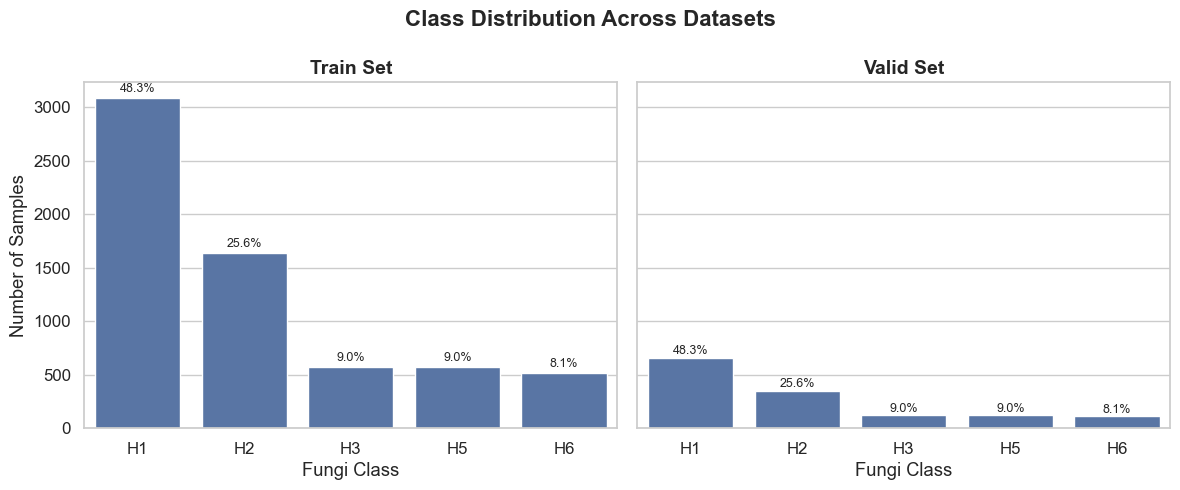

In [5]:
plot_class_distribution(train_dataloader, valid_dataloader)

There is Class Imbalance, so we use weighted loss

### Displaying sample images

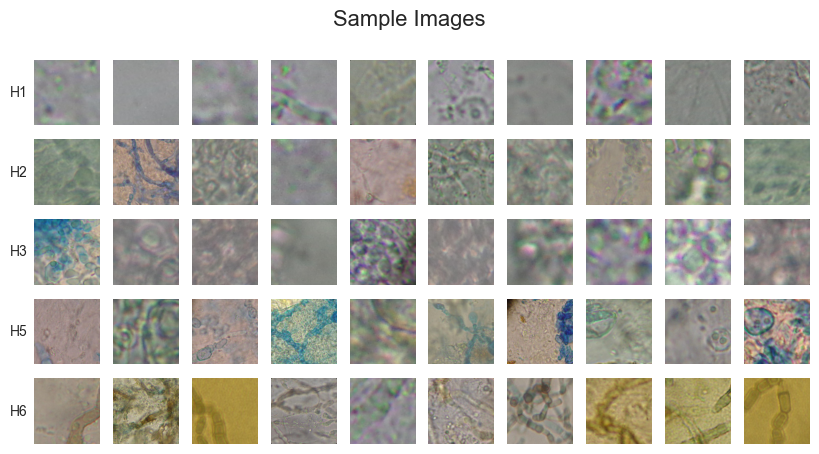

In [6]:
display_sample_images(train_dataloader, samples_per_class=10, save_path='../assets/sample_images.png')

### PyTorch Inference

In [7]:
from src.inference.preprocess import get_inference_transform, load_image, preprocess_image
from src.inference.inference_utils import format_predictions, get_top_k_predictions, load_model_from_checkpoint, predict_proba
from src.utils.device import get_device

In [8]:
model_path = '../training_runs/test_run_2/test_run_2_best.pth'
image_path = '../data/train/H6/H6_1b_1.jpg'
top_k = 5

In [9]:
device = get_device()

# Load Model 
model, metadata = load_model_from_checkpoint(model_path, device)
idx_to_class = metadata['idx_to_class']

# Load and Preprocess image 
image = load_image(image_path)
transform = get_inference_transform()
img_tensor = preprocess_image(image, transform)

# Prediction
probs = predict_proba(model, img_tensor, device)

# Top k predictions 
results = get_top_k_predictions(
    probs,
    idx_to_class,
    top_k = top_k
)

print(format_predictions(results))


Predictions:
--------------------
Class → Probability
--------------------
H6 → 0.5991
H1 → 0.1921
H3 → 0.1041
H2 → 0.0944
H5 → 0.0103


### ONNX Inference

In [10]:
import onnxruntime as ort
import json

from src.inference.preprocess import (
    load_image,
    preprocess_image,
    get_inference_transform
)
from src.inference.inference_utils import (
    predict_onnx,
    format_predictions
)

In [11]:
onnx_path = "../training_runs/test_run_2/test_run_2_best.onnx"
metadata_path = "../training_runs/test_run_2/test_run_2_best_metadata_onnx.json"
image_path = '../data/train/H6/H6_1b_1.jpg'
top_k = 5

In [12]:
# Load ONNX session
session = ort.InferenceSession(
    onnx_path,
    providers=["CPUExecutionProvider"]
)

# Load metadata
with open(metadata_path) as f:
    metadata = json.load(f)

idx_to_class = {int(k): v for k, v in metadata["idx_to_class"].items()}

# Load image
image = load_image(image_path)
transform = get_inference_transform()
img_tensor = preprocess_image(image, transform)

# Predict
results = predict_onnx(
    session,
    img_tensor,
    idx_to_class,
    top_k=top_k
)

# Output
print(format_predictions(results))


Predictions:
--------------------
Class → Probability
--------------------
H6 → 0.5991
H1 → 0.1921
H3 → 0.1041
H2 → 0.0944
H5 → 0.0103
